# Medidas de concentración

Concentración de los casos de violencia de pareja reportada entre las entidades federativas, con la curva de Lorenz y el coeficiente de Gini.

## 1. Qué son las medidas de concentración

Indican qué parte de un total se acumula en una fracción pequeña de las unidades; aquí, qué parte de los casos se acumula en pocas de las 32 entidades.

La curva de Lorenz ordena las entidades de menor a mayor número de casos y grafica la fracción acumulada de entidades contra la fracción acumulada de casos. Si todas tuvieran los mismos casos, la curva sería la diagonal; mientras más se aleja hacia abajo, mayor es la concentración.

El coeficiente de Gini resume la curva en un número. Con los valores $x_{(i)}$ ordenados de menor a mayor y $n$ unidades:

$$G = \frac{2\sum_{i=1}^{n} i\,x_{(i)} - (n+1)\sum_{i=1}^{n} x_{(i)}}{n\sum_{i=1}^{n} x_{(i)}}$$

$G = 0$ indica que todas las unidades tienen el mismo valor. El máximo no es 1 sino $\frac{n-1}{n}$; con 32 entidades es 0.9688.

Un Gini alto entre entidades no significa por sí solo que en unas haya más violencia: una entidad más poblada reúne más casos aunque la proporción de mujeres que reportan violencia sea igual. Por eso se compara con la concentración de la población y se revisa la prevalencia.

Los casos y la población de cada entidad se obtienen sumando `factor_expansion`; contar registros no serviría, porque la encuesta entrevistó a un número parecido de mujeres en cada entidad.

## 2. Datos

In [1]:
import sys
from pathlib import Path

import polars as pl
from IPython.display import Image, display

# La raíz del proyecto entra al path para importar config/ y src/.
RAIZ = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
sys.path.append(str(RAIZ))

from config.rutas import RUTA_ENDIREH_LIMPIO, RUTA_FIGURAS
from src.visualization.graficas import (
    figura_03_prevalencia_entidad,
    figura_09_curva_lorenz,
)
from src.visualization.indices import gini, seccion_concentracion, seccion_entidades

df = pl.read_parquet(RUTA_ENDIREH_LIMPIO)

columnas = ["sufrio_violencia_pareja", "factor_expansion", "nom_entidad"]
print(f"Registros: {df.height:,}")
print("Valores de sufrio_violencia_pareja:", sorted(df["sufrio_violencia_pareja"].unique().to_list()))
print("Nulos por columna:", df.select(columnas).null_count().row(0, named=True))
print("Entidades:", df["nom_entidad"].n_unique())

Registros: 105,752
Valores de sufrio_violencia_pareja: [0, 1]
Nulos por columna: {'sufrio_violencia_pareja': 0, 'factor_expansion': 0, 'nom_entidad': 0}
Entidades: 32


Las tres columnas que se usan no tienen nulos, la variable de violencia solo toma 0 y 1, y están las 32 entidades.

## 3. Resultados

### 3.1 Casos y población por entidad

In [2]:
seccion_entidades(df)


 CASOS DE VIOLENCIA DE PAREJA REPORTADA POR ENTIDAD (ponderados)

    Entidad                                Casos   % casos    Población   % pobl.   Prevalencia
    -------------------------------------------------------------------------------------------
    MÉXICO                             1,333,883     15.2%    6,879,280     14.0%         19.4%
    CIUDAD DE MÉXICO                     699,840      8.0%    4,050,571      8.2%         17.3%
    VERACRUZ DE IGNACIO DE LA LLAVE      625,007      7.1%    3,203,778      6.5%         19.5%
    JALISCO                              621,493      7.1%    3,181,394      6.5%         19.5%
    GUANAJUATO                           464,896      5.3%    2,371,622      4.8%         19.6%
    PUEBLA                               439,552      5.0%    2,549,298      5.2%         17.2%
    MICHOACÁN DE OCAMPO                  346,114      3.9%    1,787,810      3.6%         19.4%
    GUERRERO                             306,097      3.5%    1,330,2

**Interpretación.** El 17.8 % de las mujeres representadas reportó violencia de pareja. Las cuatro entidades con más casos son también las cuatro más pobladas, y en la mayoría de las entidades el porcentaje de casos y el de población difieren en menos de un punto. Las diferencias mayores aparecen donde la prevalencia se aleja de la nacional, como en Chiapas (11.2 %) y Guerrero (23.0 %).

### 3.2 Coeficiente de Gini

In [3]:
print("Cuatro unidades con el mismo valor:", gini([5, 5, 5, 5]))
print("Todo el total en una de cuatro unidades:", gini([0, 0, 0, 10]))

Cuatro unidades con el mismo valor: 0.0
Todo el total en una de cuatro unidades: 0.75


El reparto igual da 0 y la concentración total en cuatro unidades da 0.75, el máximo $\frac{4-1}{4}$.

In [4]:
seccion_concentracion(df)


 MEDIDAS DE CONCENTRACIÓN ENTRE ENTIDADES

Entidades: 32. Gini máximo posible, (n-1)/n: 0.9688

    Variable                    Gini
    --------------------------------
    Casos ponderados          0.4180
    Población                 0.4056
    Prevalencia               0.0859

Correlación entre casos y población por entidad: 0.984

    Parte del total que reúnen             Casos   Población
    --------------------------------------------------------
    Las 16 entidades con menos             23.0%       23.1%
    Las 5 entidades con más                42.7%       40.4%
    Cada columna ordena las entidades según su propio valor.


**Interpretación.** El Gini de los casos es 0.4180 sobre un máximo de 0.9688: una concentración moderada. Es casi el mismo que el de la población (0.4056), y la correlación entre casos y población por entidad es de 0.984, así que los casos se concentran donde se concentra la población. El Gini de la prevalencia, 0.0859, no mide concentración, porque la prevalencia es una tasa; indica que las 32 tasas se parecen mucho entre sí.

### 3.3 Curva de Lorenz

[graficas] reports/figuras/09_curva_lorenz_entidades.png


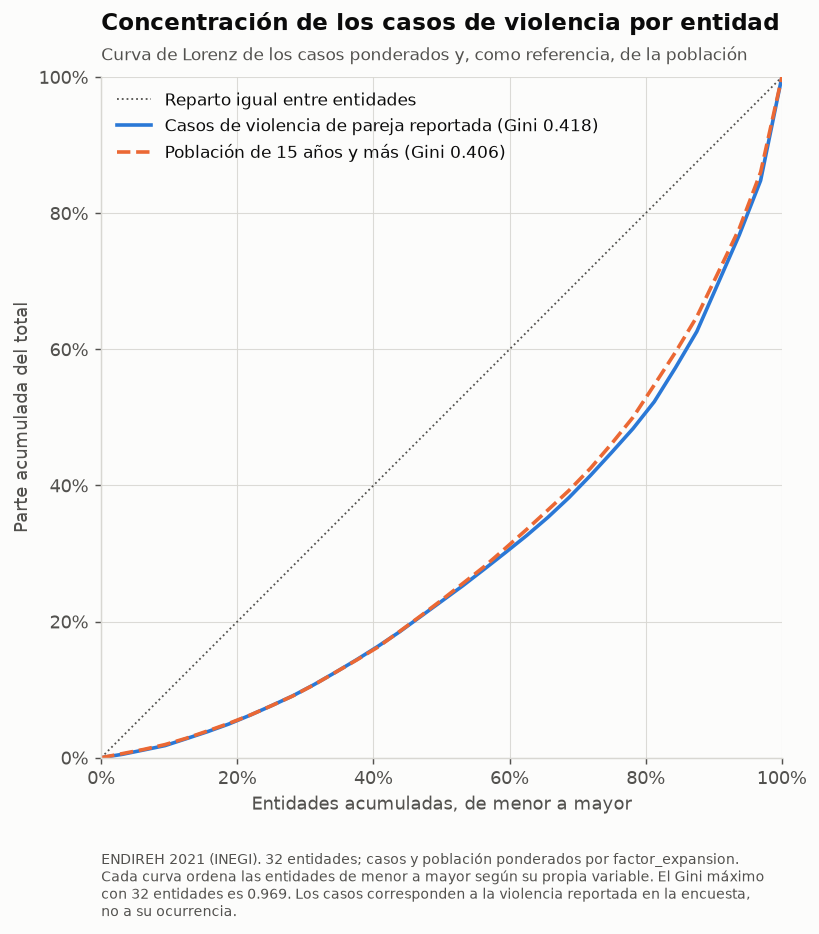

In [5]:
figura_09_curva_lorenz(df)
display(Image(filename=str(RUTA_FIGURAS / "09_curva_lorenz_entidades.png")))

**Interpretación.** La curva de los casos queda por debajo de la diagonal y casi encima de la de la población: el reparto desigual de los casos se explica casi por completo por el tamaño de la población de cada entidad.

### 3.4 Prevalencia por entidad

[graficas] reports/figuras/03_prevalencia_por_entidad.png


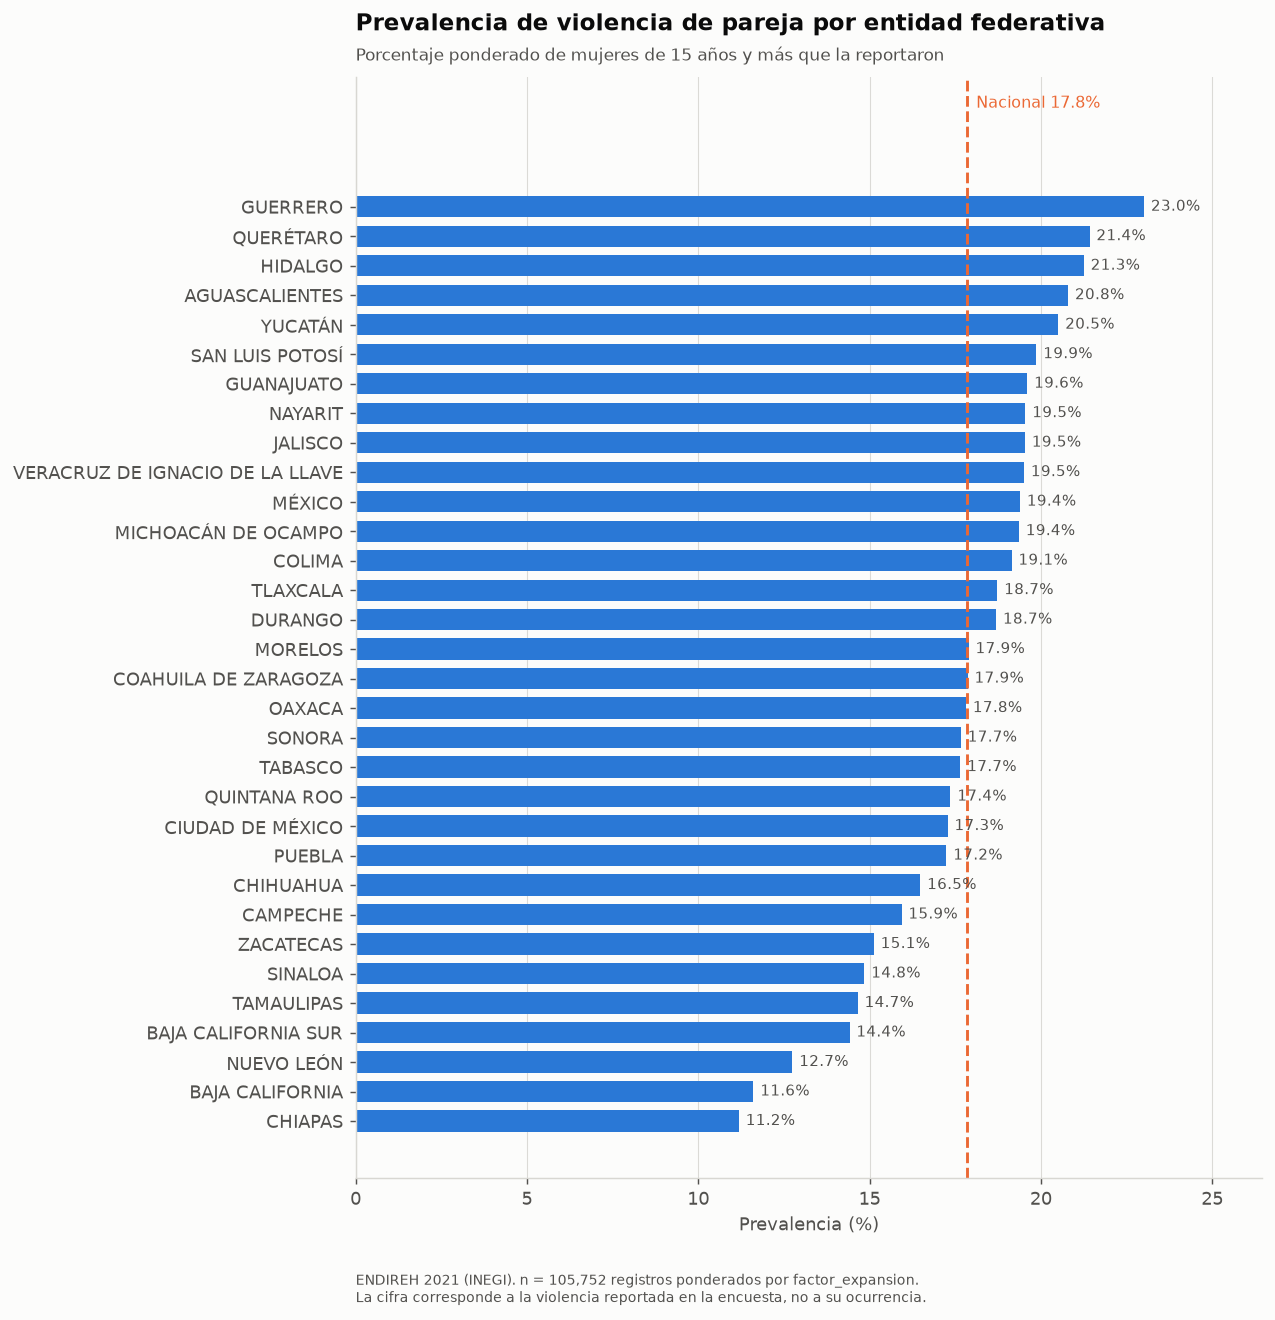

In [6]:
figura_03_prevalencia_entidad(df)
display(Image(filename=str(RUTA_FIGURAS / "03_prevalencia_por_entidad.png")))

**Interpretación.** Al dividir los casos entre la población, la prevalencia quita el efecto del tamaño: va de 11.2 % en Chiapas a 23.0 % en Guerrero, alrededor del 17.8 % nacional, y su orden no coincide con el de los casos. Estas cifras describen violencia reportada, no ocurrida; una prevalencia alta puede reflejar más violencia o mejores condiciones para reportarla, por lo que ningún orden sirve para calificar a una entidad.

## 4. Conclusión

Los casos de violencia de pareja reportada se concentran en pocas entidades en la misma medida que la población (Gini de 0.4180 y 0.4056), mientras que la prevalencia varía poco entre ellas. Una concentración alta de casos no identifica a las entidades con más violencia, ni una baja reduce la gravedad del problema donde hay menos casos.